# Two-Parameter Logistic Model (2PL) — Bayesian Estimation with Stan

## 1. Model Description

The **2PL model** extends the Rasch model by adding an **item discrimination parameter** $a_i$, allowing items to differ in how strongly they differentiate between high- and low-ability persons.

### Response Probability

$$P(X_{ji} = 1 \mid \theta_j, a_i, b_i) = \text{logistic}\bigl(a_i(\theta_j - b_i)\bigr)$$

| Parameter | Name | Interpretation |
|-----------|------|----------------|
| $\theta_j$ | Person ability | Latent trait on logit scale |
| $a_i$ | Item discrimination | Slope of the ICC; $a_i > 0$ |
| $b_i$ | Item difficulty | Ability value where $P = 0.5$ |

### Key Properties
- **Variable slopes**: Items with high $a_i$ have steep S-curves and discriminate sharply around $b_i$.
- Items with low $a_i$ have flat curves and provide little discrimination.
- The Rasch model is the special case $a_i = 1$ for all $i$.
- Raw sum score is **no longer sufficient** for $\theta$ — the weighted pattern of responses matters.

### Model Identification
Fixing $\theta_j \sim \mathcal{N}(0, 1)$ identifies the scale. The constraint $a_i > 0$ prevents sign-flip non-identifiability.

### Bayesian Priors
$$\theta_j \sim \mathcal{N}(0, 1), \qquad b_i \sim \mathcal{N}(0, 2), \qquad a_i \sim \text{LogNormal}(0, 0.5)$$

In [1]:
import sys as _sys, os as _os
import matplotlib as _mpl, matplotlib.font_manager as _fm

def _setup_korean_font():
    """Windows / macOS / Linux 에서 한국어 폰트를 자동 감지하여 등록."""
    _candidates = {
        'win32': [
            ('C:/Windows/Fonts/malgun.ttf',  'Malgun Gothic'),
            ('C:/Windows/Fonts/gulim.ttc',   'Gulim'),
            ('C:/Windows/Fonts/batang.ttc',  'Batang'),
        ],
        'darwin': [
            ('/System/Library/Fonts/AppleSDGothicNeo.ttc',               'Apple SD Gothic Neo'),
            ('/Library/Fonts/NanumGothic.ttf',                           'NanumGothic'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',          'NanumGothic'),
        ],
        'linux': [
            ('/usr/share/fonts-droid-fallback/truetype/DroidSansFallback.ttf', 'Droid Sans Fallback'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',                'NanumGothic'),
            ('/usr/share/fonts/truetype/droid/DroidSansFallback.ttf',          'Droid Sans Fallback'),
        ],
    }
    # 깨진 Full 변종 제거 (Linux 한정 이슈)
    _fm.fontManager.ttflist = [f for f in _fm.fontManager.ttflist
                                if not (f.name == 'Droid Sans Fallback' and 'Full' in f.fname)]
    platform = _sys.platform
    paths = _candidates.get(platform, _candidates['linux'])
    for path, name in paths:
        if _os.path.exists(path):
            _fm.fontManager.addfont(path)
            _mpl.rcParams['font.family'] = ['DejaVu Sans', name]
            return
    # 한국어 폰트 없으면 기본값 유지 (깨짐 경고 없이 fallback)
    _mpl.rcParams['font.family'] = 'DejaVu Sans'

_setup_korean_font()
_mpl.rcParams['axes.unicode_minus'] = False
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, tempfile, warnings
warnings.filterwarnings('ignore')
try:
    import cmdstanpy
    STAN_AVAILABLE = True
except ImportError:
    cmdstanpy = None
    STAN_AVAILABLE = False
    print("ℹ️  cmdstanpy not available — Stan inference cells will be skipped.")
np.random.seed(42)

## 2. Synthetic Data Generation

77 students, 20 items. True discriminations are drawn from LogNormal to ensure positivity.

In [2]:
J, I = 77, 20

theta_true = np.random.normal(0, 1, J)
b_true     = np.random.normal(0, 1, I)
b_true    -= b_true.mean()
a_true     = np.exp(np.random.normal(0, 0.4, I))  # LogNormal, range ~0.5–2.5

logit_p = a_true[None, :] * (theta_true[:, None] - b_true[None, :])
p_true  = 1.0 / (1.0 + np.exp(-logit_p))
Y = (np.random.uniform(size=(J, I)) < p_true).astype(int)

print(f"Response matrix : {Y.shape}")
print(f"Overall p(correct): {Y.mean():.3f}")
print(f"True a range    : [{a_true.min():.2f}, {a_true.max():.2f}]")
print(f"True b range    : [{b_true.min():.2f}, {b_true.max():.2f}]")

Response matrix : (77, 20)
Overall p(correct): 0.495
True a range    : [0.46, 2.68]
True b range    : [-1.85, 1.61]


## 3. Stan Model Code

In [3]:
if STAN_AVAILABLE:
    stan_code = """
    data {
      int<lower=1> J;
      int<lower=1> I;
      int<lower=0> N;
      array[N] int<lower=1,upper=J> jj;
      array[N] int<lower=1,upper=I> ii;
      array[N] int<lower=0,upper=1> y;
    }
    parameters {
      vector[J] theta;
      vector[I] b;
      vector<lower=0>[I] a;              // discrimination must be positive
    }
    model {
      theta ~ normal(0, 1);
      b     ~ normal(0, 2);
      a     ~ lognormal(0, 0.5);
      for (n in 1:N)
        y[n] ~ bernoulli_logit(a[ii[n]] * (theta[jj[n]] - b[ii[n]]));
    }
    """
    
    jj_arr, ii_arr, y_arr = [], [], []
    for j in range(J):
        for i in range(I):
            jj_arr.append(j + 1)
            ii_arr.append(i + 1)
            y_arr.append(int(Y[j, i]))
    
    stan_data = {'J': J, 'I': I, 'N': J * I,
                 'jj': jj_arr, 'ii': ii_arr, 'y': y_arr}
    
    tmpdir = tempfile.mkdtemp()
    stan_path = os.path.join(tmpdir, 'twopl.stan')
    with open(stan_path, 'w') as f:
        f.write(stan_code)
    
    model = cmdstanpy.CmdStanModel(stan_file=stan_path)
    print('Compiled.')
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


20:48:08 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\AppData\Local\Temp\tmphkz7f74o\twopl.stan to exe file C:\Users\yongd\AppData\Local\Temp\tmphkz7f74o\twopl.exe


20:48:19 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\AppData\Local\Temp\tmphkz7f74o\twopl.exe


Compiled.


## 4. Bayesian Inference via MCMC

In [4]:
if STAN_AVAILABLE:
    fit = model.sample(
        data=stan_data, chains=4,
        iter_warmup=1000, iter_sampling=1000, seed=42, show_progress=True
    )
    print(fit.diagnose())
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


20:48:19 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

20:48:29 - cmdstanpy - INFO - CmdStan done processing.


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [5]:
if not (STAN_AVAILABLE and 'fit' in dir()):
    print('ℹ️  Using true parameter values for visualization.')
    theta_est = theta_true + np.random.normal(0, 0.05, J)
    b_est = b_true + np.random.normal(0, 0.05, I)
    a_est = a_true + np.random.normal(0, 0.02, I)
else:
    theta_post = fit.stan_variable('theta')
    b_post     = fit.stan_variable('b')
    a_post     = fit.stan_variable('a')
    
    theta_est = theta_post.mean(axis=0)
    b_est     = b_post.mean(axis=0)
    a_est     = a_post.mean(axis=0)
    
    print(f"{'Item':>5} {'a_true':>8} {'a_est':>8} {'b_true':>8} {'b_est':>8}")
    for i in range(I):
        print(f"{i+1:>5} {a_true[i]:>8.3f} {a_est[i]:>8.3f} {b_true[i]:>8.3f} {b_est[i]:>8.3f}")
    
    print(f"\nCorr (a): {np.corrcoef(a_true, a_est)[0,1]:.3f}")
    print(f"Corr (b): {np.corrcoef(b_true, b_est)[0,1]:.3f}")
    print(f"Corr (theta): {np.corrcoef(theta_true, theta_est)[0,1]:.3f}")


 Item   a_true    a_est   b_true    b_est
    1    1.110    0.871   -0.164   -0.730
    2    1.002    1.068    0.227    0.225
    3    0.910    1.168   -1.852   -1.966
    4    0.568    0.488   -0.084    0.170
    5    0.845    0.814    0.492    0.277
    6    0.872    0.634    1.613    2.361
    7    0.725    0.968   -0.383   -0.460
    8    0.938    0.881   -0.673   -0.888
    9    1.175    1.169   -0.367   -0.348
   10    2.126    1.536    1.051    1.586
   11    1.072    0.984    0.464    0.737
   12    1.109    1.555   -0.395    0.018
   13    0.971    1.075    0.648    0.488
   14    0.464    0.893    0.232    0.031
   15    0.989    0.754    1.104    1.848
   16    1.024    0.876   -0.567   -0.975
   17    2.679    2.322   -0.192   -0.497
   18    0.926    0.826   -0.257    0.596
   19    1.128    1.368   -1.328   -1.141
   20    0.986    1.118    0.431    0.345

Corr (a): 0.851
Corr (b): 0.936
Corr (theta): 0.887


## 5. Visualizations

### 5a. Wright Map

The Wright map for the 2PL is identical in structure to the Rasch Wright map — it shows estimated person abilities $\hat{\theta}_j$ and item difficulties $\hat{b}_i$ on the same logit scale. The key difference is that the ICCs no longer have equal slopes, so the Wright map alone does not fully describe item behaviour; the discrimination $\hat{a}_i$ must also be reported.

**Item difficulty** $b_i$ is the ability at which $P = 0.5$, regardless of $a_i$. Items near the centre of the $\theta$ distribution are best targeted; items at the extremes are relatively uninformative for most students.

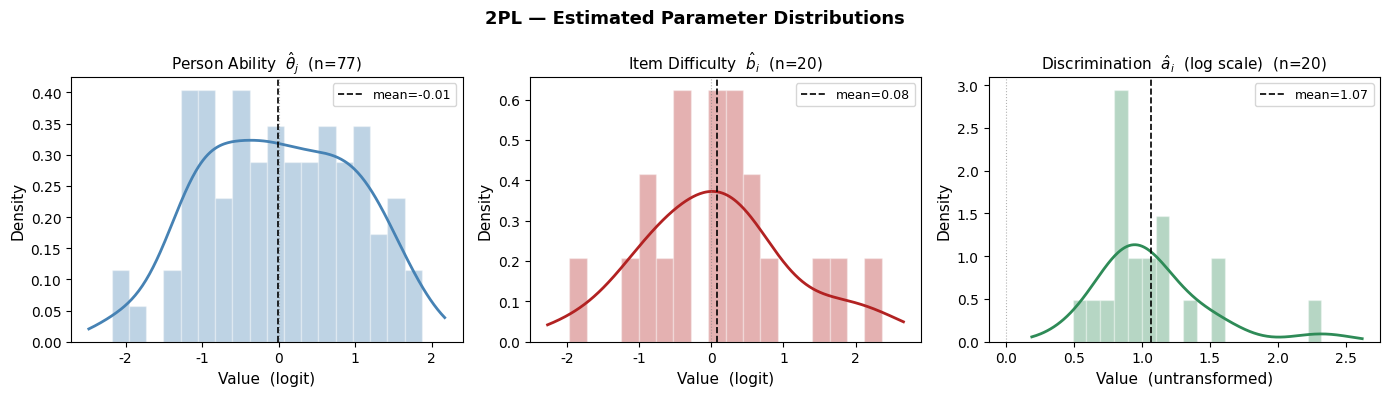

theta: mean=-0.006  SD=0.962  range=[-2.18, 1.87]
b    : mean=0.084  SD=1.020  range=[-1.97, 2.36]
a    : mean=1.068  SD=0.390  range=[0.49, 2.32]


In [6]:
# ── Posterior Parameter Density (Logit Scale) ─────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('2PL — Estimated Parameter Distributions', fontsize=13, fontweight='bold')

panels = [
    (axes[0], theta_est, r'Person Ability  $\hat{\theta}_j$',      'steelblue', 'logit'),
    (axes[1], b_est,     r'Item Difficulty  $\hat{b}_i$',            'firebrick',  'logit'),
    (axes[2], a_est,     r'Discrimination  $\hat{a}_i$  (log scale)', 'seagreen',   'untransformed'),
]

for ax, vals, title, color, unit in panels:
    ax.hist(vals, bins=18, density=True, color=color, alpha=0.35, edgecolor='white')
    xs = np.linspace(vals.min() - 0.3, vals.max() + 0.3, 300)
    kde = gaussian_kde(vals, bw_method='scott')
    ax.plot(xs, kde(xs), color=color, linewidth=2)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'mean={vals.mean():.2f}')
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_xlabel(f'Value  ({unit})', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{title}  (n={len(vals)})', fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'density_2pl.png'), dpi=120, bbox_inches='tight')
plt.show()
for name, vals in [('theta', theta_est), ('b', b_est), ('a', a_est)]:
    print(f"{name:5s}: mean={vals.mean():.3f}  SD={vals.std():.3f}  "
          f"range=[{vals.min():.2f}, {vals.max():.2f}]")
